# **Text Classification with RNN: Sentiment Analysis on IMDB Movie Reviews**


## **1. Overview and Theoretical Framework**

### **1.1 Introduction to Sentiment Analysis**

This tutorial focuses on **sentiment analysis**, a fundamental task in natural language processing that involves determining the emotional tone or attitude expressed in a text. Sentiment analysis has numerous applications in diverse fields including:

- **Market Research**: Analyzing customer opinions and product reviews
- **Social Media Monitoring**: Tracking brand perception and public sentiment
- **Customer Service**: Automatically categorizing and prioritizing support tickets
- **Political Analysis**: Gauging public opinion on policy issues and candidates

The IMDB Movie Review dataset represents a classic benchmark for binary sentiment classification, consisting of 50,000 highly polar movie reviews labeled as either positive or negative.

### **1.2 Recurrent Neural Networks for Sequence Modeling**

**Recurrent Neural Networks (RNNs)** and their variants, such as **Long Short-Term Memory (LSTM)** networks, are particularly well-suited for sequential data like text. These architectures provide several key advantages:

1. **Sequential Processing**: RNNs maintain a hidden state that captures information from previous elements in the sequence
2. **Variable Length Handling**: RNNs can process sequences of arbitrary length through recurrent connections
3. **Feature Learning**: They automatically learn relevant features from raw text without explicit feature engineering

The following diagram illustrates the basic structure of a recurrent neural network:

```
Input -> [Embedding Layer] -> [Recurrent Layer(s)] -> [Output Layer] -> Prediction
           |                      |
           |                      v
           |                 [Hidden State]
           v                      |
    Word Embeddings <-------------+
```

In this tutorial, we'll implement and compare both standard RNN and LSTM architectures, exploring their relative strengths and weaknesses for sentiment classification.

## **2. Required Libraries and Environment Setup**

In [29]:
# Import essential libraries for data processing, visualization, and deep learning
import numpy as np               # Array operations and numerical computations
import pandas as pd              # Data manipulation and analysis
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns            # Advanced data visualization
import torch                     # PyTorch deep learning framework
import torch.nn as nn            # Neural network modules
from torch.utils.data import DataLoader, TensorDataset  # Data loading utilities
from collections import Counter  # Frequency counting
from string import punctuation   # Punctuation character set
import re                        # Python Regex

# Import additional libraries
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# Set random seeds for reproducible results
torch.manual_seed(42)
np.random.seed(42)

Using cuda device


## **3. Data Exploration**


The **IMDB Movie Review Dataset** is a widely-used benchmark for sentiment analysis, containing 50,000 highly polar movie reviews labeled as either positive (1) or negative (0). Each review is represented as raw text and requires extensive preprocessing before model training.

Initial exploration of the dataset provides critical insights into its structure, including the distribution of classes and the characteristics of the text data. These insights inform subsequent preprocessing decisions and model design choices.

In [2]:
DATASET_FILENAME = 'IMDB Dataset.csv'

# Load the dataset into a pandas DataFrame for analysis
df = pd.read_csv(DATASET_FILENAME)

# Display the first few rows to examine structure
print("=== DATASET STRUCTURE ===")
print(df.head())


=== DATASET STRUCTURE ===
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
# Analyze dataset dimensions
print(f"\nDataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")

# Check for missing values
missing_values = df.isnull().sum()
print(f"\nMissing Values per Column:\n{missing_values}")




Dataset Dimensions: 50000 rows × 2 columns

Missing Values per Column:
review       0
sentiment    0
dtype: int64


In [4]:
# Examine class distribution
sentiment_counts = df['sentiment'].value_counts()
print(f"\nClass Distribution:\n{sentiment_counts}")
print(f"Class Balance Ratio: {sentiment_counts.min() / sentiment_counts.max():.4f}")




Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Class Balance Ratio: 1.0000


In [5]:
# Analyze review length statistics
df['review_length'] = df['review'].apply(len)
print("\nReview Length Statistics:")
print(df['review_length'].describe())


Review Length Statistics:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


In [7]:
# Sample review inspection
print("=== SAMPLE REVIEW ANALYSIS ===")
sample_positive = df[df['sentiment'] == 'positive'].iloc[0]
sample_negative = df[df['sentiment'] == 'negative'].iloc[0]

print("\nSample Positive Review:")
print("-" * 80)
print(sample_positive['review'][:500] + "...")  # Truncate for display clarity
print("-" * 80)
print(f"Length: {len(sample_positive['review'])} characters")

print("\nSample Negative Review:")
print("-" * 80)
print(sample_negative['review'][:500] + "...")  # Truncate for display clarity
print("-" * 80)
print(f"Length: {len(sample_negative['review'])} characters")

=== SAMPLE REVIEW ANALYSIS ===

Sample Positive Review:
--------------------------------------------------------------------------------
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ...
--------------------------------------------------------------------------------
Length: 1761 characters

Sample Negative Review:
--------------------------------------------------------------------------------
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This 

## **4. Data Preprocessing**


Text normalization is a critical preprocessing step that standardizes the format of the text data, reducing the dimensionality and noise in the input space. Common normalization techniques include:

1. **Case Normalization**: Converting all text to lowercase to treat words like "Good" and "good" as the same token
2. **Removing th html tags**: Usually most of these textss are extracted from website source code(html code), hence we see texts like \<br\>, \<br \/>, etc because they are html codes interleaved with the actual texts. These entities has to be removed to get a clean sentence.
3. **Punctuation Removal**: Eliminating punctuation marks that generally don't carry sentiment information
4. **Special Character Handling**: Removing or replacing special characters and symbols

These preprocessing steps help create a more standardized representation of the text, improving the generalization capabilities of the model.

In [8]:
# Step 1: Case normalization - Convert all text to lowercase
print("Applying case normalization...")
df['review_normalized'] = df['review'].apply(lambda x: x.lower())

# Display example of case normalization effect
print("\nCase Normalization Example:")
original_text = df['review'].iloc[1][:100]
normalized_text = df['review_normalized'].iloc[1][:100]
print(f"Original: {original_text}...")
print(f"Normalized: {normalized_text}...")

Applying case normalization...

Case Normalization Example:
Original: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-B...
Normalized: a wonderful little production. <br /><br />the filming technique is very unassuming- very old-time-b...


In [9]:
# Step 2: Remove HTML tags
print("Removing HTML tags...")
df['review_no_html'] = df['review_normalized'].apply(
    lambda x: re.sub(r'<.*?>', '', x)
)

# Display example of HTML tag removal effect
print("\nHTML Tag Removal Example:")
before_html_removal = df['review_normalized'].iloc[1][:150]
after_html_removal = df['review_no_html'].iloc[1][:150]

print(f"Before: {before_html_removal}...")
print(f"After : {after_html_removal}...")

Removing HTML tags...



HTML Tag Removal Example:
Before: a wonderful little production. <br /><br />the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes d...
After : a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting...


In [10]:
# Step 2: Punctuation removal

print("\nPunctuation characters to remove:")
print(punctuation) # this is a prebuilt python function we imported at start                         

# Remove all punctuation characters from the normalized text
print("\nApplying punctuation removal...")
df['clean_text'] = df['review_no_html'].apply(lambda x: ''.join(' ' if c in punctuation else c for c in x))

# Display example of punctuation removal effect
print("\nPunctuation Removal Example:")
normalized_with_punct = df['review_no_html'].iloc[1][:100]
cleaned_text = df['clean_text'].iloc[1][:100]
print(f"Before: {normalized_with_punct}...")
print(f"After: {cleaned_text}...")


Punctuation characters to remove:
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

Applying punctuation removal...

Punctuation Removal Example:
Before: a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion a...
After: a wonderful little production  the filming technique is very unassuming  very old time bbc fashion a...


In [11]:
# Step 4: Calculate text length after preprocessing
df['clean_text_length'] = df['clean_text'].apply(len)

# Display the first few rows of the preprocessed dataset
print("\nPreprocessed Dataset Preview:")
display(df[['sentiment', 'review_length', 'clean_text_length']].head())

# Analyze the effect of preprocessing on text length
length_reduction = (df['review_length'].mean() - df['clean_text_length'].mean()) / df['review_length'].mean() * 100
print(f"\nAverage text length reduction: {length_reduction:.2f}%")

# Display updated dataset statistics after preprocessing
print("\nPreprocessed Dataset Statistics:")
print(f"Total reviews: {len(df)}")
print(f"Average clean text length: {df['clean_text_length'].mean():.2f} characters")
print(f"Median clean text length: {df['clean_text_length'].median():.2f} characters")


Preprocessed Dataset Preview:


,sentiment,review_length,clean_text_length
0,positive,1761,1725
1,positive,998,962
2,positive,926,902
3,negative,748,712
4,positive,1317,1269



Average text length reduction: 1.85%

Preprocessed Dataset Statistics:
Total reviews: 50000
Average clean text length: 1285.17 characters
Median clean text length: 953.00 characters


## **5. Text Tokenization and Encoding**

### **5.1 Vocabulary Construction**

Tokenization involves breaking down text into smaller units (tokens), which are then mapped to numerical indices. This process creates a vocabulary that serves as the foundation for word embeddings.

The steps involved in vocabulary construction include:

1. Splitting text into individual words
2. Counting word frequencies to identify common terms
3. Creating a word-to-index mapping for numerical representation
4. Handling special tokens (e.g., padding, unknown words)

This approach transforms raw text into structured numerical data suitable for neural network processing.

In [12]:
# Step 1: Create a corpus of all cleaned text for vocabulary construction
print("Creating corpus for vocabulary construction...")
all_text = ' '.join(df['clean_text'].tolist())

# Step 2: Split corpus into individual words
words = all_text.split()
print(f"Total words in corpus: {len(words):,}")

# Step 3: Count word frequencies
print("\nCalculating word frequencies...")
word_counts = Counter(words)
total_unique_words = len(word_counts)
print(f"Total unique words (vocabulary size): {total_unique_words:,}")

# Display the most common words
print("\nMost common words in vocabulary:")
for word, count in word_counts.most_common(10):
    print(f"  {word}: {count:,} occurrences")

# Display the least common words
print("\nLeast common words in vocabulary:")
for word, count in word_counts.most_common()[:-11:-1]:
    print(f"  {word}: {count} occurrences")

Creating corpus for vocabulary construction...
Total words in corpus: 11,773,826

Calculating word frequencies...
Total unique words (vocabulary size): 105,124

Most common words in vocabulary:
  the: 667,665 occurrences
  and: 324,296 occurrences
  a: 322,860 occurrences
  of: 289,377 occurrences
  to: 268,067 occurrences
  is: 211,048 occurrences
  it: 190,682 occurrences
  in: 186,714 occurrences
  i: 175,408 occurrences
  this: 150,908 occurrences

Least common words in vocabulary:
  movie8: 1 occurrences
  clatter: 1 occurrences
  effortful: 1 occurrences
  ashknenazi: 1 occurrences
  jossi: 1 occurrences
  burtolucci: 1 occurrences
  censorial: 1 occurrences
  angelyne: 1 occurrences
  nolin: 1 occurrences
  kman: 1 occurrences


In [13]:
# Step 4: Create word-to-index mapping (vocabulary)
print("\nCreating word-to-index mapping...")

# Sort words by frequency (most common first) to optimize index assignments
sorted_words = word_counts.most_common(total_unique_words)

# Create word-to-index dictionary
# We add +1 to all indices to reserve index 0 for padding
vocab_to_int = {word: idx+1 for idx, (word, _) in enumerate(sorted_words)}

# Display vocabulary statistics
print(f"Vocabulary created with {len(vocab_to_int):,} words")
print(f"Index range: 1 to {len(vocab_to_int):,}")
print("Index 0 reserved for padding")

# Display sample of the vocabulary
print("\nVocabulary sample (word: index):")
sample_items = list(vocab_to_int.items())[:10]
for word, index in sample_items:
    print(f"  {word}: {index}")


Creating word-to-index mapping...
Vocabulary created with 105,124 words
Index range: 1 to 105,124
Index 0 reserved for padding

Vocabulary sample (word: index):
  the: 1
  and: 2
  a: 3
  of: 4
  to: 5
  is: 6
  it: 7
  in: 8
  i: 9
  this: 10


### **5.2 Review Encoding and Label Processing**

After constructing the vocabulary, we need to:
1. Convert each review from words to integer sequences using the vocabulary mapping
2. Transform categorical sentiment labels into numerical values (binary classification)

These steps complete the data transformation process, preparing the dataset for neural network training.

In [14]:
# Step 1: Prepare reviews for encoding
reviews_split = df['clean_text'].tolist()

# Step 2: Encode reviews as integer sequences
print("Encoding reviews as integer sequences...")
reviews_encoded = []

for review in reviews_split:
    # Convert each word in the review to its corresponding integer index
    encoded_review = [vocab_to_int[word] for word in review.split() if word in vocab_to_int]
    reviews_encoded.append(encoded_review)

# Display example of encoded reviews
print("\nExample of encoded reviews:")
print(f"Original text: {reviews_split[0][:50]}...")
print(f"Encoded sequence: {reviews_encoded[0][:20]}...")

# Display statistics about encoded reviews
review_lengths = [len(review) for review in reviews_encoded]
print(f"\nEncoded review statistics:")
print(f"  Minimum length: {min(review_lengths)} tokens")
print(f"  Maximum length: {max(review_lengths)} tokens")
print(f"  Average length: {np.mean(review_lengths):.2f} tokens")
print(f"  Median length: {np.median(review_lengths):.2f} tokens")

Encoding reviews as integer sequences...



Example of encoded reviews:
Original text: one of the other reviewers has mentioned that afte...
Encoded sequence: [28, 4, 1, 77, 2062, 46, 1062, 11, 100, 149, 41, 308, 3105, 398, 20, 232, 29, 3211, 32, 25]...

Encoded review statistics:
  Minimum length: 6 tokens
  Maximum length: 2498 tokens
  Average length: 235.48 tokens
  Median length: 177.00 tokens


In [46]:
# Step 3: Encode sentiment labels
print("\nEncoding sentiment labels...")
sentiment_categories = df['sentiment'].tolist()

# Convert sentiment categories to binary labels (1 for positive, 0 for negative)
encoded_labels = np.array([1 if label == 'positive' else 0 for label in sentiment_categories])

# Display example of encoded labels
print("\nExample of encoded labels:")
print(f"Original label: {sentiment_categories[0]}")
print(f"Encoded label: {encoded_labels[0]}")


Encoding sentiment labels...

Example of encoded labels:
Original label: positive
Encoded label: 1


## **6. Dataset Preparation for Neural Networks**

### **6.1 Sequence Standardization**

Neural networks typically require fixed-size inputs, but our encoded reviews have variable lengths. To address this challenge, we need to standardize all sequences to the same length through:

1. **Padding**: Adding zeros to shorter sequences
2. **Truncation**: Shortening excessively long sequences

This process enables batch processing and proper tensor operations in the neural network architecture. The sequence length is an important hyperparameter that balances information retention with computational efficiency.

In [ ]:
# Define a function to standardize sequence lengths through padding and truncation
def pad_features(reviews_int, seq_length):
    """
    Return features of review_ints, where each review is padded with zeros or
    truncated to the input seq_length.

    Parameters:
    -----------
    reviews_int : List[List[int]]
        List of reviews where each review is a list of integer word indices
    seq_length : int
        Fixed sequence length for all reviews

    Returns:
    --------
    features : np.ndarray
        Array of padded/truncated integer sequences with shape (len(reviews_int), seq_length)
    """
    # Initialize an array of zeros with shape (n_reviews, seq_length)
    features = np.zeros((len(reviews_int), seq_length), dtype=int)

    # Iterate through reviews
    for i, review in enumerate(reviews_int):
        review_len = len(review)

        # Handle short sequences: add padding zeros at the beginning
        if review_len <= seq_length:
            zeros = list(np.zeros(seq_length - review_len, dtype=int))
            # Place zeros at the beginning for more effective learning
            # (RNNs prioritize later sequence elements)
            new_sequence = zeros + review

        # Handle long sequences: truncate to seq_length
        else:
            # Preserve the most recent part of the review (recency effect)
            new_sequence = review[-seq_length:]

        # Store the padded/truncated sequence
        features[i, :] = np.array(new_sequence)

    return features




# Determine optimal sequence length
# Common approach: Choose a value that preserves most reviews while limiting excessive padding
seq_length = 200  # This captures a significant portion of the reviews



print(f"Standardizing sequences to length: {seq_length}")
# Apply padding/truncation
padded_features = pad_features(reviews_encoded, seq_length)

# Display statistics on standardized sequences
print(f"\nStandardized sequence shape: {padded_features.shape}")
print(f"  Number of sequences: {padded_features.shape[0]}")
print(f"  Sequence length: {padded_features.shape[1]} tokens")

# Verify pad_features implementation with examples
print("\nExample of standardized sequences:")
print("Short review (padded):")
short_idx = np.argmin([len(r) for r in reviews_encoded])
print(f"  Original length: {len(reviews_encoded[short_idx])} tokens")
print(f"  Padded sequence: {padded_features[short_idx, :20]} ... (zeros are padding)")

print("\nLong review (truncated):")
long_idx = np.argmax([len(r) for r in reviews_encoded])
print(f"  Original length: {len(reviews_encoded[long_idx])} tokens")
print(f"  Truncated sequence: {padded_features[long_idx, :20]} ...")

Standardizing sequences to length: 200

Standardized sequence shape: (50000, 200)
  Number of sequences: 50000
  Sequence length: 200 tokens

Example of standardized sequences:
Short review (padded):
  Original length: 6 tokens
  Padded sequence: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ... (zeros are padding)

Long review (truncated):
  Original length: 2498 tokens
  Truncated sequence: [ 344  124  826  191   26 4936   55 2704  760    5 6368  748   18   24
   97 4277   43    1  748  191] ...


### **6.2 Dataset Partitioning**

To properly evaluate model performance and prevent overfitting, we divide the dataset into three distinct subsets: **Train**, **Validation** and **Test** sets 

In [47]:
# Create data splits for training, validation, and testing
print("Partitioning dataset into training, validation, and testing sets...")

# Calculate split indices
total_samples = len(padded_features)
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

train_end = int(train_ratio * total_samples)
val_end = train_end + int(val_ratio * total_samples)

# Split features
X_train = padded_features[:train_end]
X_val = padded_features[train_end:val_end]
X_test = padded_features[val_end:]

# Split labels
y_train = encoded_labels[:train_end]
y_val = encoded_labels[train_end:val_end]
y_test = encoded_labels[val_end:]

# Verify split sizes
print("\nDataset Partitioning Results:")
print(f"  Total samples: {total_samples}")
print(f"  Training set: {len(X_train)} samples ({len(X_train)/total_samples*100:.1f}%)")
print(f"  Validation set: {len(X_val)} samples ({len(X_val)/total_samples*100:.1f}%)")
print(f"  Test set: {len(X_test)} samples ({len(X_test)/total_samples*100:.1f}%)")

# Verify class distribution across splits
print("\nClass Distribution Across Splits:")
print(f"  Full dataset: {np.mean(encoded_labels)*100:.1f}% positive")
print(f"  Training set: {np.mean(y_train)*100:.1f}% positive")
print(f"  Validation set: {np.mean(y_val)*100:.1f}% positive")
print(f"  Test set: {np.mean(y_test)*100:.1f}% positive")

Partitioning dataset into training, validation, and testing sets...

Dataset Partitioning Results:
  Total samples: 50000
  Training set: 40000 samples (80.0%)
  Validation set: 5000 samples (10.0%)
  Test set: 5000 samples (10.0%)

Class Distribution Across Splits:
  Full dataset: 50.0% positive
  Training set: 50.0% positive
  Validation set: 50.7% positive
  Test set: 49.4% positive


### **6.3 PyTorch DataLoader Configuration**

The final step in dataset preparation is creating PyTorch DataLoader objects, which provide:

1. **Efficient Batch Processing**: Loading data in mini-batches to optimize GPU memory usage
2. **Shuffling**: Randomizing the order of training samples to prevent order-dependent biases
3. **Parallel Data Loading**: Utilizing multiple worker processes for faster data retrieval
4. **Automatic Conversion**: Transforming NumPy arrays into PyTorch tensors

These DataLoaders serve as the interface between the preprocessed data and the neural network training loop.

In [48]:
# Convert NumPy arrays to PyTorch tensors
print("Creating PyTorch datasets and dataloaders...")

# Create TensorDatasets for each split
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

# Configure batch size
batch_size = 64

# Create DataLoader objects
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)  # No need to shuffle test data

# Display DataLoader configuration
print("\nDataLoader Configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Display a sample batch
print("\nSample batch inspection:")
sample_x, sample_y = next(iter(train_loader))
print(f"  Input batch shape: {sample_x.shape}")  # [batch_size, sequence_length]
print(f"  Label batch shape: {sample_y.shape}")  # [batch_size]


Creating PyTorch datasets and dataloaders...

DataLoader Configuration:
  Batch size: 64
  Training batches: 625
  Validation batches: 79
  Test batches: 79

Sample batch inspection:
  Input batch shape: torch.Size([64, 200])
  Label batch shape: torch.Size([64])


## **7. Model Architecture Design**

### **7.1 RNN Model for Sentiment Classification**

The first architecture we'll implement is a standard Recurrent Neural Network (RNN). This architecture includes:

1. **Embedding Layer**: Transforms integer tokens into dense vector representations
2. **RNN Layer(s)**: Processes the sequence data, maintaining hidden state across timesteps
3. **Dropout**: Regularizes the network to prevent overfitting
4. **Linear Layer**: Maps the final hidden state to a sentiment prediction
5. **Sigmoid Activation**: Produces a probability output for binary classification

The RNN architecture serves as our baseline model, providing a foundation for comparison with more advanced recurrent architectures.

In [49]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=drop_prob
        )

        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(hidden_dim, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size = x.size(0)

        # Convert token ids to embeddings
        embeds = self.embedding(x)
        # embeds: (batch_size, seq_len, embedding_dim)

        # Initialize hidden state h0 with zeros
        h0 = torch.zeros(
            self.n_layers,
            batch_size,
            self.hidden_dim,
            device=x.device
        )

        # Pass embeddings and initial hidden state to RNN
        rnn_out, _ = self.rnn(embeds, h0)
        # rnn_out: (batch_size, seq_len, hidden_dim)

        # Take output from last time step
        last_output = rnn_out[:, -1, :]
        # last_output: (batch_size, hidden_dim)

        out = self.dropout(last_output)
        out = self.fc(out)
        out = self.sigmoid(out)

        return out

In [50]:

# Instantiate the RNN model with hyperparameters
print("Initializing RNN model architecture...")

# Model hyperparameters
vocab_size = len(vocab_to_int) + 1  # +1 for padding token (0)
output_size = 1  # Binary classification
embedding_dim = 400  # Word embedding dimension
hidden_dim = 256  # Hidden state dimension
n_layers = 2  # Number of RNN layers

# Create model instance
rnn_model = SentimentRNN(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)

# Display model architecture summary
print(rnn_model)


Initializing RNN model architecture...
SentimentRNN(
  (embedding): Embedding(105125, 400)
  (rnn): RNN(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### **7.2. Long Short-Term Memory (LSTM) Architecture**

The LSTM architecture for sentiment analysis follows the same high-level pattern as our RNN:
1. **Embedding Layer**: Converts word indices to dense vectors
2. **LSTM Layer(s)**: Processes sequential data with specialized memory cells
3. **Dropout Layer**: Applies regularization to prevent overfitting
4. **Fully Connected Layer**: Maps LSTM outputs to classification scores
5. **Sigmoid Activation**: Produces probability output for binary classification


In [51]:
import torch
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=drop_prob
        )

        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(hidden_dim, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size = x.size(0)

        # Convert token ids to embeddings
        embeds = self.embedding(x)
        # embeds: (batch_size, seq_len, embedding_dim)

        # Initialize hidden state h0 and cell state c0 with zeros
        h0 = torch.zeros(
            self.n_layers,
            batch_size,
            self.hidden_dim,
            device=x.device
        )

        c0 = torch.zeros(
            self.n_layers,
            batch_size,
            self.hidden_dim,
            device=x.device
        )

        # Pass embeddings and initial states to LSTM
        lstm_out, _ = self.lstm(embeds, (h0, c0))
        # lstm_out: (batch_size, seq_len, hidden_dim)

        # Take output from last time step
        last_output = lstm_out[:, -1, :]
        # last_output: (batch_size, hidden_dim)

        out = self.dropout(last_output)
        out = self.fc(out)
        out = self.sigmoid(out)

        return out

In [52]:

# Instantiate the LSTM model with the same hyperparameters as the RNN for fair comparison
print("Initializing LSTM model architecture...")

# Create model instance (using same hyperparameters as RNN)
lstm_model = SentimentLSTM(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)

# Display model architecture summary
print(lstm_model)


Initializing LSTM model architecture...
SentimentLSTM(
  (embedding): Embedding(105125, 400)
  (lstm): LSTM(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## **8. Training Configuration**


In [53]:
# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)


# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Move models to device
rnn_model = rnn_model.to(device)
lstm_model = lstm_model.to(device)

# Training hyperparameters
batch_size = 50
learning_rate = 0.001
epochs = 5


Training on: cuda


In [54]:


# Loss function
criterion = nn.BCELoss()

# Optimizers - one for each model
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)



# Training monitoring variables
train_loss_history = {'rnn': [], 'lstm': []}
val_loss_history = {'rnn': [], 'lstm': []}
val_accuracy_history = {'rnn': [], 'lstm': []}
best_val_loss = {'rnn': float('inf'), 'lstm': float('inf')}
patience_counter = {'rnn': 0, 'lstm': 0}

# Display configuration summary
print("\n--- Training Configuration ---")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Loss Function: {criterion.__class__.__name__}")
print(f"Optimizer: Adam")


# Create directory for saving models if it doesn't exist
import os
if not os.path.exists('models'):
    os.makedirs('models')
    print("Created directory 'models/' for saving trained models")


--- Training Configuration ---
Batch Size: 50
Learning Rate: 0.001
Epochs: 5
Loss Function: BCELoss
Optimizer: Adam
Early Stopping Patience: 3
Learning Rate Scheduler: ReduceLROnPlateau


## **9. Model Training and Evaluation**


In [55]:
def calculate_metrics(y_pred, y_true, threshold=0.5):
    """
    Calculate classification metrics from model predictions.

    Parameters:
    -----------
    y_pred : torch.Tensor or numpy.ndarray
        Predicted probabilities
    y_true : torch.Tensor or numpy.ndarray
        Ground truth labels
    threshold : float, default=0.5
        Threshold for binary classification

    Returns:
    --------
    dict
        Dictionary containing accuracy, precision, recall, and F1-score
    """
    # Convert tensors to numpy if needed
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.cpu().detach().numpy()
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().detach().numpy()

    # Convert probabilities to binary predictions using threshold
    y_pred_binary = (y_pred > threshold).astype(int)

    # Calculate metrics
    accuracy = np.mean(y_pred_binary == y_true)

    # Prevent division by zero
    tp = np.sum((y_pred_binary == 1) & (y_true == 1))
    fp = np.sum((y_pred_binary == 1) & (y_true == 0))
    fn = np.sum((y_pred_binary == 0) & (y_true == 1))

    # Calculate precision, recall, and F1-score
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [67]:

def validate(model, val_loader, criterion, device, model_type=None):
    """
    Validate model on validation set.
    Works for simplified RNN/LSTM models with internal hidden-state initialization.
    """
    model.eval()

    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs.squeeze(), labels)
            total_val_loss += loss.item()

            # Store predictions and labels
            all_preds.extend(outputs.squeeze().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    metrics = calculate_metrics(np.array(all_preds), np.array(all_labels))

    return avg_val_loss, metrics


def test_model(model, test_loader, criterion, device, model_type=None):
    """
    Test model on test set.
    Works for simplified RNN/LSTM models with internal hidden-state initialization.
    """
    model.eval()

    total_test_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs.squeeze(), labels)
            total_test_loss += loss.item()

            # Store predictions and labels
            all_preds.extend(outputs.squeeze().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)
    metrics = calculate_metrics(np.array(all_preds), np.array(all_labels))

    return avg_test_loss, metrics

In [68]:

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    device,
    model_type,
    patience=3,
    min_delta=0.0
):
    """
    Train the model with validation and early stopping.
    Works for both simplified RNN and LSTM models
    where hidden states are initialized inside forward().
    """

    model.to(device)

    train_losses = []
    val_losses = []
    val_metrics = []

    best_val_loss = float('inf')
    patience_counter = 0

    start_time = time.time()

    print(f"\n=== Training {model_type.upper()} Model ===")

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        # -------------------- TRAIN --------------------
        model.train()
        total_train_loss = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs.squeeze(), labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # -------------------- VALIDATION --------------------
        val_loss, metrics = validate(model, val_loader, criterion, device, model_type)
        val_losses.append(val_loss)
        val_metrics.append(metrics)

        epoch_time = time.time() - epoch_start

        # -------------------- LOGGING --------------------
        print(f"Epoch {epoch}/{epochs} | Time: {epoch_time:.2f}s")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Accuracy: {metrics['accuracy']:.4f}")
        print(
            f"  Val Precision: {metrics['precision']:.4f} | "
            f"Val Recall: {metrics['recall']:.4f} | "
            f"Val F1: {metrics['f1_score']:.4f}"
        )

        # -------------------- EARLY STOPPING --------------------
        if val_loss < best_val_loss - min_delta:
            print(f"  Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}")

            best_val_loss = val_loss
            patience_counter = 0

            torch.save(model.state_dict(), f"models/{model_type}_best.pt")
            print(f"  Saved best model to models/{model_type}_best.pt")

        else:
            patience_counter += 1
            print(f"  Validation loss did not improve. Patience: {patience_counter}/{patience}")

           

    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time:.2f} seconds")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_metrics": val_metrics,
        "best_val_loss": best_val_loss,
        "training_time": total_time
    }

In [69]:

# Train RNN model
print("\n" + "="*50)
print("BEGINNING RNN TRAINING")
print("="*50)
rnn_history = train_model(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=rnn_optimizer,
    criterion=criterion,
    epochs=epochs,
    device=device,
    model_type='rnn'
)



BEGINNING RNN TRAINING

=== Training RNN Model ===
Epoch 1/5 | Time: 13.62s
  Train Loss: 0.6337
  Val Loss: 0.6413 | Val Accuracy: 0.6332
  Val Precision: 0.6179 | Val Recall: 0.7261 | Val F1: 0.6676
  Validation loss improved from inf to 0.6413
  Saved best model to models/rnn_best.pt
Epoch 2/5 | Time: 13.51s
  Train Loss: 0.5734
  Val Loss: 0.5794 | Val Accuracy: 0.7218
  Val Precision: 0.7388 | Val Recall: 0.6989 | Val F1: 0.7182
  Validation loss improved from 0.6413 to 0.5794
  Saved best model to models/rnn_best.pt
Epoch 3/5 | Time: 13.60s
  Train Loss: 0.5081
  Val Loss: 0.5482 | Val Accuracy: 0.7296
  Val Precision: 0.7658 | Val Recall: 0.6728 | Val F1: 0.7163
  Validation loss improved from 0.5794 to 0.5482
  Saved best model to models/rnn_best.pt
Epoch 4/5 | Time: 13.72s
  Train Loss: 0.4645
  Val Loss: 0.5445 | Val Accuracy: 0.7826
  Val Precision: 0.8561 | Val Recall: 0.6870 | Val F1: 0.7623
  Validation loss improved from 0.5482 to 0.5445
  Saved best model to models/rnn

In [70]:

# Train LSTM model
print("\n" + "="*50)
print("BEGINNING LSTM TRAINING")
print("="*50)
lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=lstm_optimizer,
    criterion=criterion,
    epochs=epochs,
    device=device,
    model_type='lstm'
)


BEGINNING LSTM TRAINING

=== Training LSTM Model ===
Epoch 1/5 | Time: 36.56s
  Train Loss: 0.5371
  Val Loss: 0.4600 | Val Accuracy: 0.7810
  Val Precision: 0.8140 | Val Recall: 0.7367 | Val F1: 0.7734
  Validation loss improved from inf to 0.4600
  Saved best model to models/lstm_best.pt
Epoch 2/5 | Time: 36.43s
  Train Loss: 0.3292
  Val Loss: 0.2929 | Val Accuracy: 0.8760
  Val Precision: 0.8632 | Val Recall: 0.8979 | Val F1: 0.8802
  Validation loss improved from 0.4600 to 0.2929
  Saved best model to models/lstm_best.pt
Epoch 3/5 | Time: 36.47s
  Train Loss: 0.2088
  Val Loss: 0.2903 | Val Accuracy: 0.8784
  Val Precision: 0.8441 | Val Recall: 0.9326 | Val F1: 0.8861
  Validation loss improved from 0.2929 to 0.2903
  Saved best model to models/lstm_best.pt
Epoch 4/5 | Time: 36.90s
  Train Loss: 0.1842
  Val Loss: 0.2820 | Val Accuracy: 0.8838
  Val Precision: 0.8601 | Val Recall: 0.9208 | Val F1: 0.8894
  Validation loss improved from 0.2903 to 0.2820
  Saved best model to model

### **9.2. Model Evaluation and Comparison**


In [71]:
# Load best models
rnn_model.load_state_dict(torch.load('models/rnn_best.pt'))
lstm_model.load_state_dict(torch.load('models/lstm_best.pt'))

# Evaluate on test set
print("\n--- Evaluating Models on Test Set ---")

# Test RNN model
print("\nRNN Model Performance:")
rnn_test_loss, rnn_metrics = test_model(rnn_model, test_loader, criterion, device, 'rnn')
print(f"Test Loss: {rnn_test_loss:.4f}")
print(f"Test Accuracy: {rnn_metrics['accuracy']:.4f}")
print(f"Test Precision: {rnn_metrics['precision']:.4f}")
print(f"Test Recall: {rnn_metrics['recall']:.4f}")
print(f"Test F1-Score: {rnn_metrics['f1_score']:.4f}")

# Test LSTM model
print("\nLSTM Model Performance:")
lstm_test_loss, lstm_metrics = test_model(lstm_model, test_loader, criterion, device, 'lstm')
print(f"Test Loss: {lstm_test_loss:.4f}")
print(f"Test Accuracy: {lstm_metrics['accuracy']:.4f}")
print(f"Test Precision: {lstm_metrics['precision']:.4f}")
print(f"Test Recall: {lstm_metrics['recall']:.4f}")
print(f"Test F1-Score: {lstm_metrics['f1_score']:.4f}")



/tmp/ipykernel_1419413/1974166190.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rnn_model.load_state_dict(torch.load('models/rnn_best.pt'))
/tmp/ipykernel_1419413/1974


--- Evaluating Models on Test Set ---

RNN Model Performance:
Test Loss: 0.5384
Test Accuracy: 0.7390
Test Precision: 0.7545
Test Recall: 0.6992
Test F1-Score: 0.7258

LSTM Model Performance:
Test Loss: 0.2933
Test Accuracy: 0.8840
Test Precision: 0.8566
Test Recall: 0.9190
Test F1-Score: 0.8867


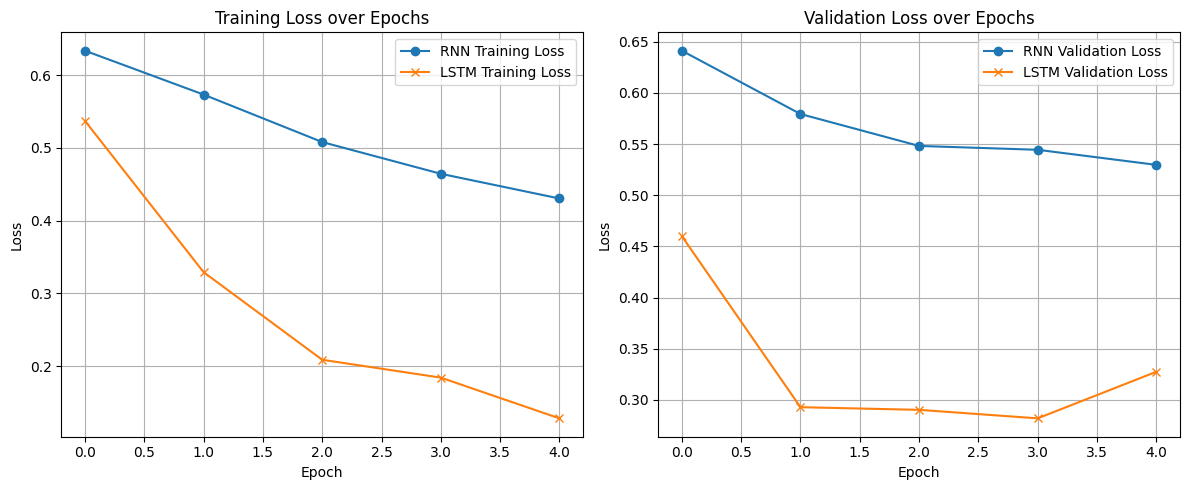

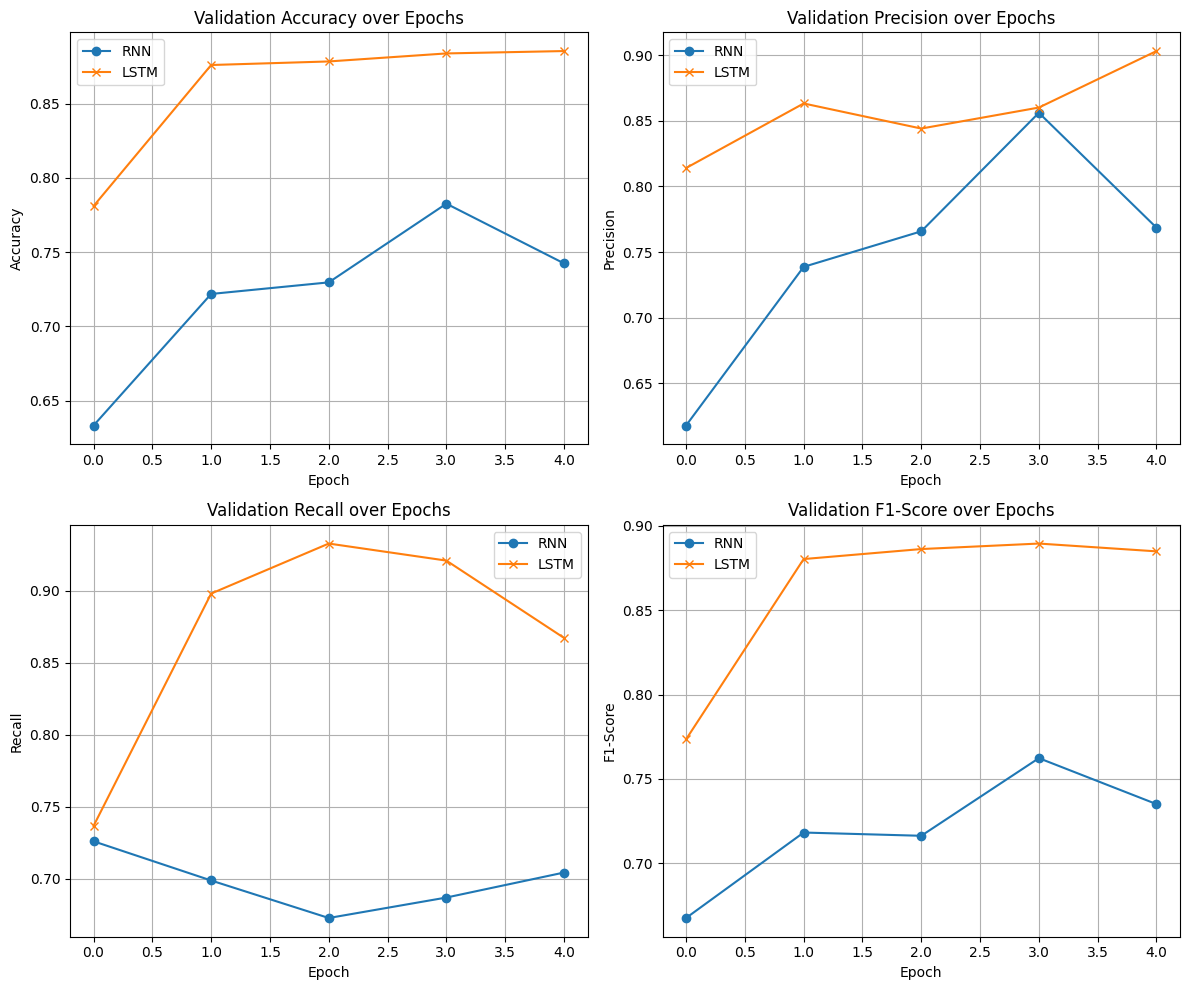

In [72]:
# Visualize training and validation loss
plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(rnn_history['train_losses'], label='RNN Training Loss', marker='o')
plt.plot(lstm_history['train_losses'], label='LSTM Training Loss', marker='x')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot validation loss
plt.subplot(1, 2, 2)
plt.plot(rnn_history['val_losses'], label='RNN Validation Loss', marker='o')
plt.plot(lstm_history['val_losses'], label='LSTM Validation Loss', marker='x')
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Extract validation accuracy from metrics
rnn_val_accuracy = [m['accuracy'] for m in rnn_history['val_metrics']]
lstm_val_accuracy = [m['accuracy'] for m in lstm_history['val_metrics']]

# Visualize validation metrics
plt.figure(figsize=(12, 10))

# Plot validation accuracy
plt.subplot(2, 2, 1)
plt.plot(rnn_val_accuracy, label='RNN', marker='o')
plt.plot(lstm_val_accuracy, label='LSTM', marker='x')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot validation precision
plt.subplot(2, 2, 2)
plt.plot([m['precision'] for m in rnn_history['val_metrics']], label='RNN', marker='o')
plt.plot([m['precision'] for m in lstm_history['val_metrics']], label='LSTM', marker='x')
plt.title('Validation Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# Plot validation recall
plt.subplot(2, 2, 3)
plt.plot([m['recall'] for m in rnn_history['val_metrics']], label='RNN', marker='o')
plt.plot([m['recall'] for m in lstm_history['val_metrics']], label='LSTM', marker='x')
plt.title('Validation Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

# Plot validation F1-score
plt.subplot(2, 2, 4)
plt.plot([m['f1_score'] for m in rnn_history['val_metrics']], label='RNN', marker='o')
plt.plot([m['f1_score'] for m in lstm_history['val_metrics']], label='LSTM', marker='x')
plt.title('Validation F1-Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



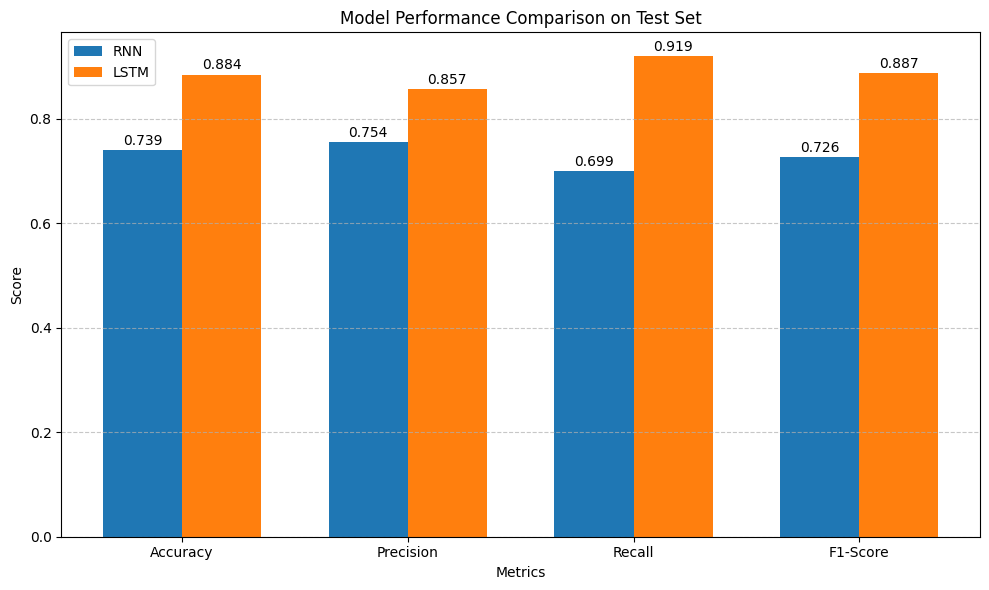

In [73]:
# Create a bar chart for test metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rnn_values = [rnn_metrics['accuracy'], rnn_metrics['precision'],
              rnn_metrics['recall'], rnn_metrics['f1_score']]
lstm_values = [lstm_metrics['accuracy'], lstm_metrics['precision'],
               lstm_metrics['recall'], lstm_metrics['f1_score']]

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, rnn_values, width, label='RNN')
plt.bar(x + width/2, lstm_values, width, label='LSTM')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison on Test Set')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, v in enumerate(rnn_values):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center')

for i, v in enumerate(lstm_values):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## **10. Model Inference with User Input**


In [83]:
import torch
import re
import string

def predict_sentiment(model, review_text, device, vocab_to_int, sequence_length=200):
    """
    Predict sentiment of a review using a trained RNN/LSTM model.
    """

    model.eval()

    # -------------------- PREPROCESS TEXT --------------------
    review_text = review_text.lower()

    # Remove HTML tags
    review_text = re.sub(r'<.*?>', '', review_text)

    # Remove punctuation
    punctuation = string.punctuation
    review_text = ''.join(' ' if c in punctuation else c for c in review_text)

    # Tokenize
    words = review_text.split()

    # Convert words to integer ids
    word_indices = [
        vocab_to_int[word] if word in vocab_to_int else 0
        for word in words
    ]

    # -------------------- PAD / TRUNCATE --------------------
    if len(word_indices) > sequence_length:
        word_indices = word_indices[-sequence_length:]
    else:
        padding = [0] * (sequence_length - len(word_indices))
        word_indices = padding + word_indices

    # Convert to tensor: shape (1, seq_len)
    inputs = torch.tensor(word_indices, dtype=torch.long).unsqueeze(0).to(device)

    # -------------------- INFERENCE --------------------
    with torch.no_grad():
        output = model(inputs)

    prob = output.item()

    sentiment = "Positive" if prob >= 0.5 else "Negative"
    confidence = prob if prob >= 0.5 else (1 - prob)

    return sentiment, confidence * 100

In [86]:
def analyze_review(review_text):
    """
    Analyze a review using both trained RNN and LSTM models.
    """

    print("\n" + "=" * 60)

    if len(review_text) > 100:
        print(f"Analyzing review: {review_text[:100]}...")
    else:
        print(f"Analyzing review: {review_text}")

    print("=" * 60)

    # Predict using both models
    rnn_sentiment, rnn_confidence = predict_sentiment(
        rnn_model, review_text, device, vocab_to_int
    )

    lstm_sentiment, lstm_confidence = predict_sentiment(
        lstm_model, review_text, device, vocab_to_int
    )

    # Show results
    print("\nResults:")
    print(f"RNN Model  : {rnn_sentiment} (Confidence: {rnn_confidence:.2f}%)")
    print(f"LSTM Model : {lstm_sentiment} (Confidence: {lstm_confidence:.2f}%)")

    # Compare predictions
    if rnn_sentiment == lstm_sentiment:
        print(
            f"\nBoth models agree: This review expresses "
            f"{rnn_sentiment.lower()} sentiment."
        )
    else:
        print("\nModels disagree on sentiment classification.")
        print(f"RNN predicts  {rnn_sentiment.lower()} ({rnn_confidence:.2f}%)")
        print(f"LSTM predicts {lstm_sentiment.lower()} ({lstm_confidence:.2f}%)")
        print("You may want to trust the higher-confidence prediction.")

In [ ]:

# Test with a few example reviews
example_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start to finish.",
    "I was very disappointed with this film. The characters were poorly developed and the story made no sense at all.",
    "It was an okay movie. Some parts were good but others were boring. Not great, not terrible.",
    "The special effects were amazing but everything else about this movie was terrible."
]

# Analyze each example review
for i, review in enumerate(example_reviews):
    print(f"\nExample {i+1}:")
    analyze_review(review)





Example 1:

Analyzing review: This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start t...

Results:
RNN Model  : Positive (Confidence: 80.51%)
LSTM Model : Positive (Confidence: 98.32%)

Both models agree: This review expresses positive sentiment.

Example 2:

Analyzing review: I was very disappointed with this film. The characters were poorly developed and the story made no s...

Results:
RNN Model  : Negative (Confidence: 94.49%)
LSTM Model : Negative (Confidence: 99.08%)

Both models agree: This review expresses negative sentiment.

Example 3:

Analyzing review: It was an okay movie. Some parts were good but others were boring. Not great, not terrible.

Results:
RNN Model  : Negative (Confidence: 94.11%)
LSTM Model : Negative (Confidence: 96.40%)

Both models agree: This review expresses negative sentiment.

Example 4:

Analyzing review: The special effects were amazing but everything else about this movie was terrible.

Results:
RNN Mode

In [88]:
# Interactive input for user reviews
print("\n" + "="*60)
print("Enter your own movie review to analyze (or type 'exit' to quit):")
print("="*60)

while True:
    user_input = input("\nEnter a movie review: ")
    if user_input.lower() == 'exit':
        print("Exiting sentiment analysis.")
        break
    if not user_input.strip():
        print("Please enter a review or type 'exit'.")
        continue

    analyze_review(user_input)


Enter your own movie review to analyze (or type 'exit' to quit):

Analyzing review: this is a pathetic movie

Results:
RNN Model  : Negative (Confidence: 93.93%)
LSTM Model : Negative (Confidence: 98.29%)

Both models agree: This review expresses negative sentiment.
Exiting sentiment analysis.
